# LLM Fingerprints

Stylometric and association-rule analysis of ChatGPT, Gemini, and Claude responses from the lmsys/chatbot_arena_conversations dataset.

**Phase 1**: Data mining & dual-track preprocessing
**Phase 2**: Stylometric profiling (structural fingerprints)
**Phase 3**: Association rule mining (semantic fingerprints)
**Phase 4**: Synthesis & visualization

In [14]:
import re
import random
import warnings
from pathlib import Path
from collections import Counter

import certifi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

warnings.filterwarnings("ignore")

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

FIG_DIR = Path("reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

random.seed(42)
np.random.seed(42)

In [15]:

DATA_PATH = next(Path("src/dataset").glob("*.parquet"))
print("Using dataset:", DATA_PATH)

Using dataset: src/dataset/train-00000-of-00001-cced8514c7ed782a(1).parquet


## Phase 1.1 - Dataset Extraction

Load the dataset, filter to ChatGPT / Gemini / Claude model labels, and group the assistant response text into three corpuses.

In [16]:
df = pd.read_parquet(DATA_PATH)

In [17]:
LABELS = {
    "ChatGPT": ["gpt"],
    "Claude": ["claude"],
    "Gemini": ["gemini", "bard", "palm"],  # Google since dataset predates Gemini
}


def classify(model_name):
    m = str(model_name).lower()
    for label, keys in LABELS.items():
        if any(k in m for k in keys):
            return label
    return None


def assistant_text(conversation):
    parts = [t["content"] for t in conversation if t.get("role") == "assistant"]
    return " ".join(parts).strip()


corpus = {"ChatGPT": [], "Claude": [], "Gemini": []}
for _, row in df.iterrows():
    for model_col, conv_col in [("model_a", "conversation_a"), ("model_b", "conversation_b")]:
        label = classify(row[model_col])
        if label is None:
            continue
        text = assistant_text(row[conv_col])
        if text:
            corpus[label].append(text)

for model, texts in corpus.items():
    print(f"{model}: {len(texts)} responses")

ChatGPT: 9967 responses
Claude: 6553 responses
Gemini: 2955 responses


In [18]:
MAX_PER_MODEL = 4000
for model in corpus:
    if len(corpus[model]) > MAX_PER_MODEL:
        corpus[model] = random.sample(corpus[model], MAX_PER_MODEL)

{model: len(texts) for model, texts in corpus.items()}

{'ChatGPT': 4000, 'Claude': 4000, 'Gemini': 2955}

## Phase 1.2 - Dual-Track Preprocessing

**Track A (Stylometrics)**: the raw text is kept exactly as generated.
**Track B (Association Mining)**: lowercase, tokenize, drop standard stop words, but keep stylistic transition words.

In [19]:
STOP = set(stopwords.words("english"))

# Stylistic transition words we explicitly retain despite being stop words.
KEEP = {
    "however", "firstly", "secondly", "thirdly", "moreover", "furthermore",
    "additionally", "therefore", "thus", "delve", "crucial", "nuanced",
    "overall", "essentially", "notably", "ultimately",
}
STOP = STOP - KEEP


def track_b_tokens(text):
    tokens = word_tokenize(text.lower())
    return [t for t in tokens if t.isalpha() and t not in STOP]


tokens_by_model = {
    model: [track_b_tokens(t) for t in texts] for model, texts in corpus.items()
}

for model, docs in tokens_by_model.items():
    print(model, "example tokens:", docs[0][:15] if docs else [])

ChatGPT example tokens: ['masculinity', 'social', 'construct', 'varies', 'across', 'different', 'cultures', 'time', 'periods', 'traditionally', 'key', 'qualities', 'associated', 'masculinity', 'include']
Claude example tokens: ['upon', 'reflection', 'feel', 'comfortable', 'generating', 'content', 'involving', 'harmful', 'stereotypes']
Gemini example tokens: ['letter', 'l', 'missing', 'list', 'letters', 'provided', 'missing', 'letter', 'l', 'letter', 'l', 'letter', 'english', 'alphabet', 'consonant']


## Phase 2 - Stylometric Profiling

Aggregate structural statistics per corpus: sentence length mean/variance, type-token ratio, and markdown / punctuation density per 1,000 words.

(TTR is reported the standard way, unique words / total words.)

In [20]:
def stylometrics(texts):
    sentence_lengths = []
    all_tokens = []
    bullets = bold = code = colon = semicolon = emdash = 0

    for t in texts:
        for sentence in sent_tokenize(t):
            words = [w for w in word_tokenize(sentence) if w.isalpha()]
            if words:
                sentence_lengths.append(len(words))

        all_tokens.extend(w.lower() for w in word_tokenize(t) if w.isalpha())

        bullets += len(re.findall(r"(?m)^\s*[\*\-]\s", t))
        bold += t.count("**") // 2
        code += t.count("```") // 2
        colon += t.count(":")
        semicolon += t.count(";")
        emdash += t.count("\u2014") + t.count("--")

    total_words = len(all_tokens)
    unique_words = len(set(all_tokens))

    def per_1k(count):
        return 1000 * count / total_words if total_words else 0.0

    return {
        "responses": len(texts),
        "avg_sentence_len": float(np.mean(sentence_lengths)) if sentence_lengths else 0.0,
        "sentence_len_var": float(np.var(sentence_lengths)) if sentence_lengths else 0.0,
        "ttr": unique_words / total_words if total_words else 0.0,
        "bullets_per_1k": per_1k(bullets),
        "bold_per_1k": per_1k(bold),
        "code_per_1k": per_1k(code),
        "colon_per_1k": per_1k(colon),
        "semicolon_per_1k": per_1k(semicolon),
        "emdash_per_1k": per_1k(emdash),
    }


stats = {model: stylometrics(texts) for model, texts in corpus.items()}
stats_df = pd.DataFrame(stats).T
stats_df

,responses,avg_sentence_len,sentence_len_var,ttr,bullets_per_1k,bold_per_1k,code_per_1k,colon_per_1k,semicolon_per_1k,emdash_per_1k
ChatGPT,4000.0,17.383867,183.977859,0.068372,4.321018,0.152175,1.027651,19.668146,2.865023,0.796570
Claude,4000.0,14.736347,144.382374,0.066671,5.887096,0.064442,0.916502,17.254589,2.262615,0.956599
Gemini,2955.0,15.423918,114.022514,0.038382,11.979418,4.476839,1.121661,13.046172,1.766812,0.770652


## Phase 3 - Association Rule Mining

Treat each response as a transaction and its unique words as items. Run Apriori per model and keep rules that pass support, confidence, and lift thresholds.

In [21]:
def mine_rules(token_lists, top_vocab=150, min_support=0.02, min_conf=0.3, min_lift=1.0):
    freq = Counter()
    for toks in token_lists:
        freq.update(set(toks))
    vocab = {w for w, _ in freq.most_common(top_vocab)}

    transactions = [sorted(set(toks) & vocab) for toks in token_lists]
    transactions = [t for t in transactions if t]

    te = TransactionEncoder()
    onehot = pd.DataFrame(te.fit_transform(transactions), columns=te.columns_)

    frequent = apriori(onehot, min_support=min_support, use_colnames=True)
    rules = association_rules(frequent, metric="lift", min_threshold=min_lift)
    rules = rules[(rules["confidence"] >= min_conf) & (rules["support"] >= min_support)]
    return rules.sort_values("lift", ascending=False).reset_index(drop=True)


rules_by_model = {model: mine_rules(tokens_by_model[model]) for model in corpus}
for model, rules in rules_by_model.items():
    print(f"{model}: {len(rules)} rules")

ChatGPT: 224 rules
Claude: 10941 rules
Gemini: 77468 rules


In [22]:
def show_rules(rules, n=10):
    out = rules.head(n).copy()
    out["antecedents"] = out["antecedents"].apply(lambda s: ", ".join(s))
    out["consequents"] = out["consequents"].apply(lambda s: ", ".join(s))
    return out[["antecedents", "consequents", "support", "confidence", "lift"]]

for model, rules in rules_by_model.items():
    print(f"\n{model}")
    display(show_rules(rules))


ChatGPT


,antecedents,consequents,support,confidence,lift
0,"language, ai","model, however",0.028998,0.461187,13.498446
1,"model, however","language, ai",0.028998,0.848739,13.498446
2,"model, ai","language, however",0.028998,0.480952,12.885824
3,"language, however","model, ai",0.028998,0.776923,12.885824
4,"model, provide","language, ai",0.030146,0.807692,12.845627
5,"language, ai","model, provide",0.030146,0.479452,12.845627
6,"language, provide","model, ai",0.030146,0.760870,12.619565
7,"model, ai","language, provide",0.030146,0.500000,12.619565
8,"information, language","model, ai",0.020959,0.744898,12.354665
9,"model, ai","information, language",0.020959,0.347619,12.354665



Claude


,antecedents,consequents,support,confidence,lift
0,"helps, questions, like, let","know, summary, hope",0.022747,0.387255,8.053511
1,"know, summary, hope","helps, questions, like, let",0.022747,0.473054,8.053511
2,"know, let, summary, hope","helps, questions, like",0.022747,0.473054,7.936793
3,"helps, questions, like","know, summary, hope",0.022747,0.381643,7.936793
4,"know, summary, hope","helps, questions, like",0.022747,0.473054,7.936793
5,"helps, questions, like","know, let, summary, hope",0.022747,0.381643,7.936793
6,"know, helps, questions, like","let, summary, hope",0.022747,0.383495,7.880939
7,"let, summary, hope","know, helps, questions, like",0.022747,0.467456,7.880939
8,"helps, questions, like","hope, summary, let",0.022747,0.381643,7.842867
9,"hope, summary, let","helps, questions, like",0.022747,0.467456,7.842867



Gemini


,antecedents,consequents,support,confidence,lift
0,"know, hope","questions, let",0.020716,0.648352,26.007120
1,"questions, let","know, hope",0.020716,0.830986,26.007120
2,"hope, let","know, questions",0.020716,0.719512,25.938870
3,"know, questions","hope, let",0.020716,0.746835,25.938870
4,"questions, hope","know, let",0.020716,0.719512,18.628825
5,"know, let","questions, hope",0.020716,0.536364,18.628825
6,"range, also",wide,0.023876,0.739130,16.976157
7,wide,"range, also",0.023876,0.548387,16.976157
8,"feedback, error, believe, model","us, please, send",0.061447,1.000000,16.274286
9,"feedback, us, model, error","please, believe, send",0.061447,1.000000,16.274286


## Phase 4 - Synthesis & Visualization

### Stylometric radar chart

In [23]:
metrics = ["ttr", "sentence_len_var", "markdown_density", "punctuation_density"]
radar = pd.DataFrame(index=list(corpus.keys()), columns=metrics, dtype=float)

for model in corpus:
    s = stats[model]
    radar.loc[model, "ttr"] = s["ttr"]
    radar.loc[model, "sentence_len_var"] = s["sentence_len_var"]
    radar.loc[model, "markdown_density"] = s["bullets_per_1k"] + s["bold_per_1k"] + s["code_per_1k"]
    radar.loc[model, "punctuation_density"] = s["colon_per_1k"] + s["semicolon_per_1k"] + s["emdash_per_1k"]

#normalize each metric to [0, 1]
norm = (radar - radar.min()) / (radar.max() - radar.min())
norm = norm.fillna(0.0)
norm

,ttr,sentence_len_var,markdown_density,punctuation_density
ChatGPT,1.000000,1.000000,0.000000,1.000000
Claude,0.943301,0.433989,0.113206,0.631307
Gemini,0.000000,0.000000,1.000000,0.000000


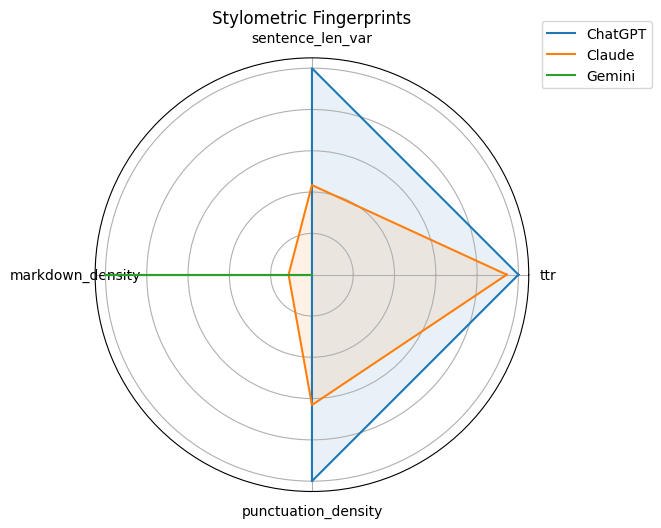

In [24]:
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"polar": True})
for model in norm.index:
    values = norm.loc[model].tolist()
    values += values[:1]
    ax.plot(angles, values, label=model)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
ax.set_yticklabels([])
ax.set_title("Stylometric Fingerprints")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig(FIG_DIR / "stylometric_radar.png", dpi=150)
plt.show()

### Association networks
Top 20 highest-lift rules per model as a directed graph.

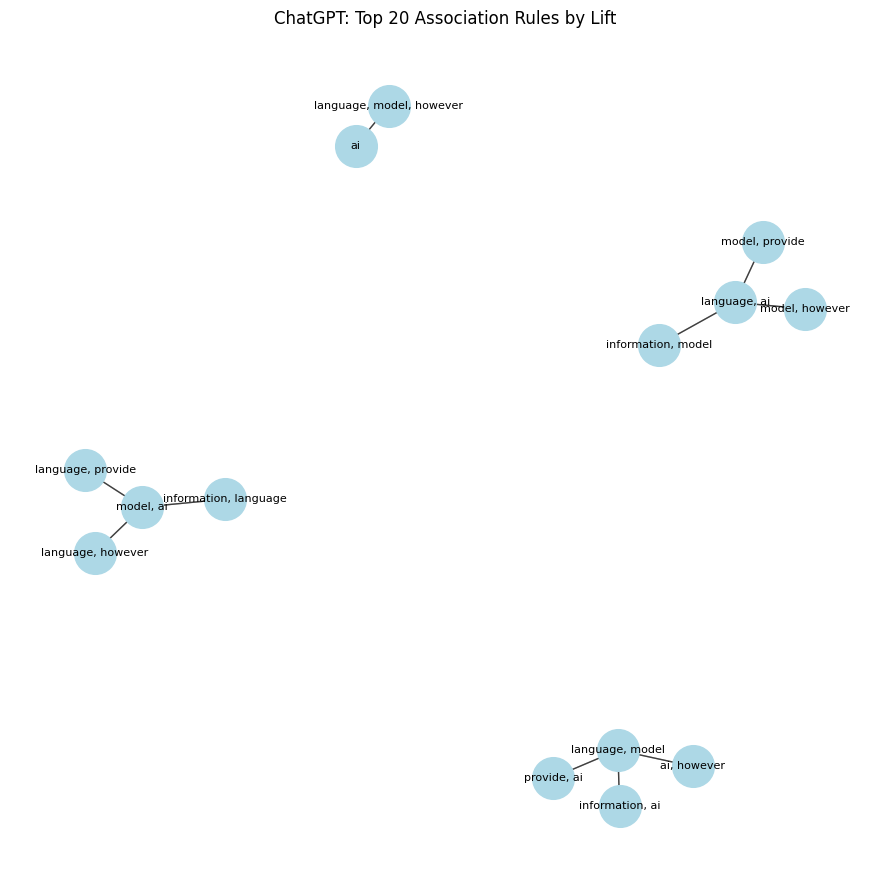

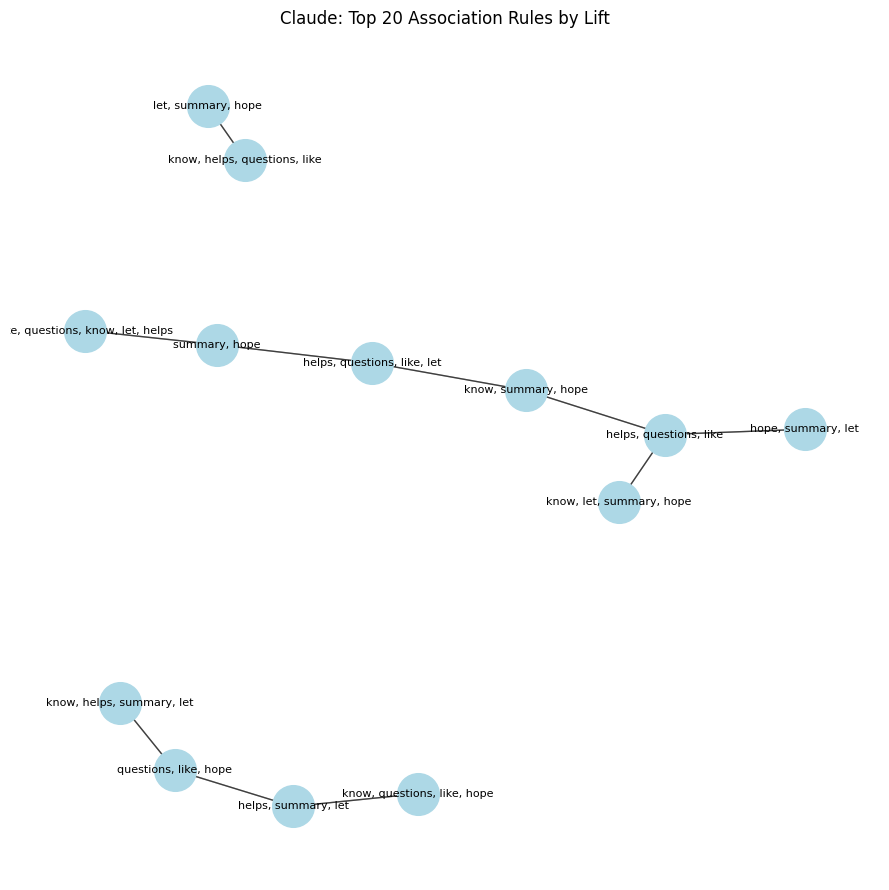

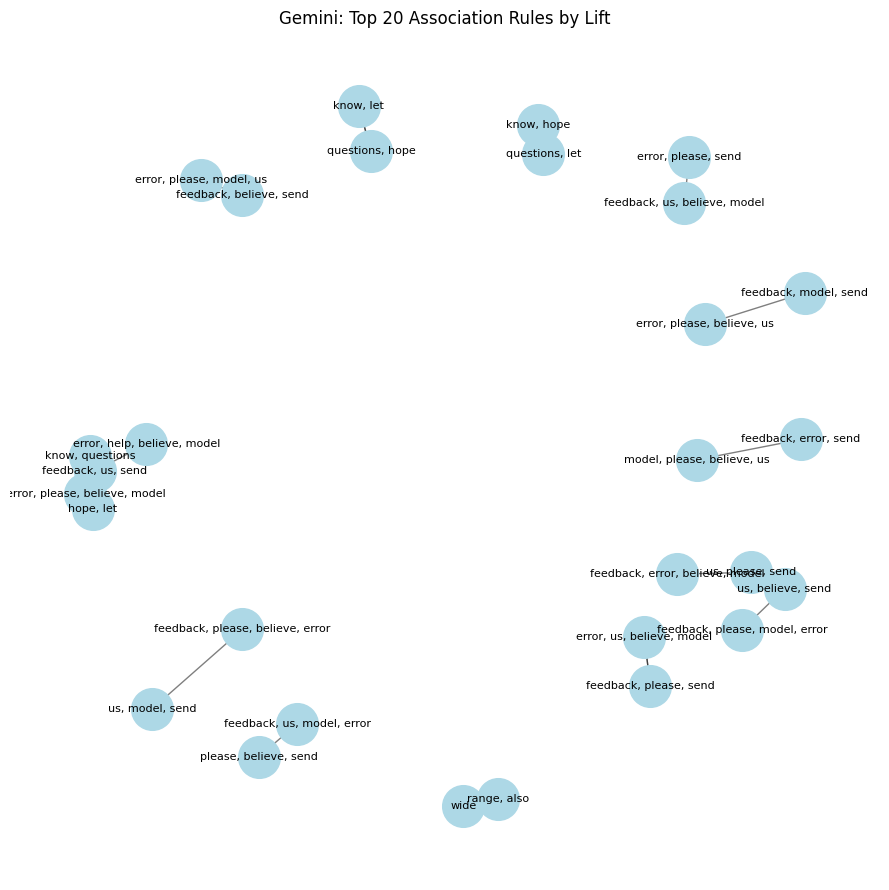

In [25]:
def plot_network(rules, model, filename):
    top = rules.head(20)
    G = nx.DiGraph()
    for _, r in top.iterrows():
        a = ", ".join(r["antecedents"])
        c = ", ".join(r["consequents"])
        G.add_edge(a, c, weight=float(r["lift"]))

    fig, ax = plt.subplots(figsize=(9, 9))
    if len(G) == 0:
        ax.text(0.5, 0.5, "No rules passed the thresholds", ha="center")
        ax.axis("off")
    else:
        pos = nx.spring_layout(G, seed=42, k=0.7)
        nx.draw_networkx_nodes(G, pos, node_color="lightblue", node_size=900, ax=ax)
        nx.draw_networkx_edges(G, pos, arrows=True, ax=ax, alpha=0.5)
        nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
        ax.set_title(f"{model}: Top {len(top)} Association Rules by Lift")
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=150)
    plt.show()


plot_network(rules_by_model["ChatGPT"], "ChatGPT", "association_network_chatgpt.png")
plot_network(rules_by_model["Claude"], "Claude", "association_network_claude.png")
plot_network(rules_by_model["Gemini"], "Gemini", "association_network_gemini.png")